In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned dataset from Week 1
df = pd.read_csv('../data/superstore_cleaned.csv')

# Parse date columns
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset successfully loaded: 9994 rows, 25 columns.


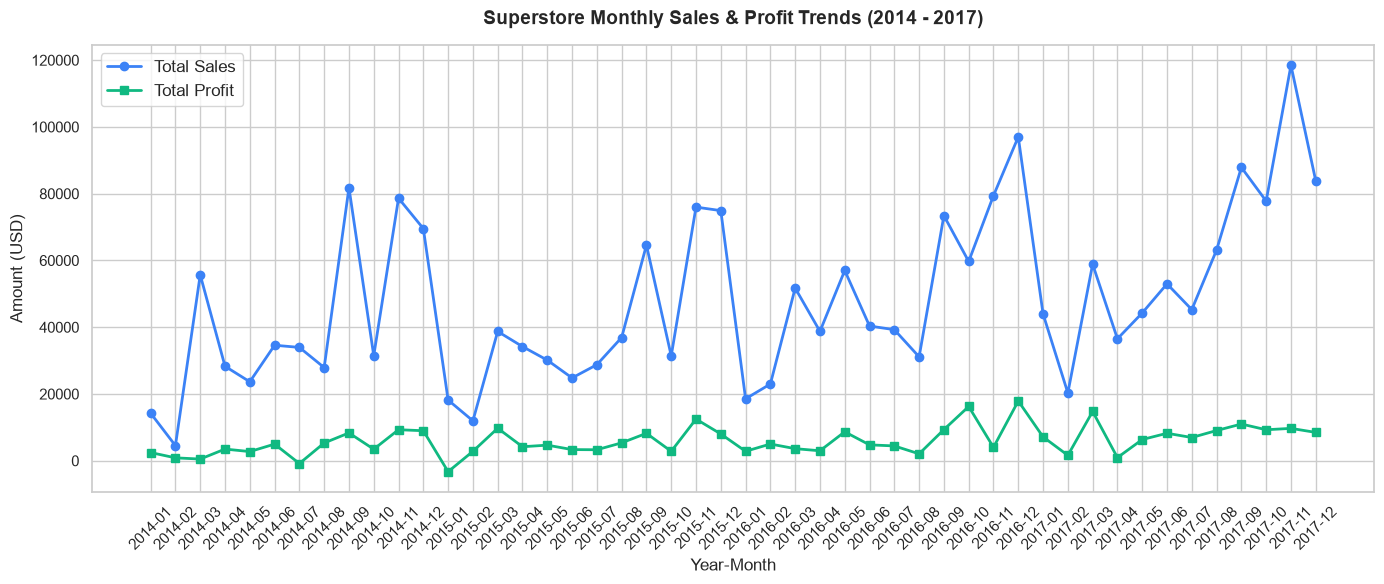

In [2]:
# Group by year_month and aggregate sales and profit
monthly_trends = df.groupby('year_month')[['sales', 'profit']].sum().reset_index()

# Plot Monthly Sales and Profit Trends
plt.figure(figsize=(14, 6))
plt.plot(monthly_trends['year_month'], monthly_trends['sales'], marker='o', label='Total Sales', color='#3b82f6', linewidth=2)
plt.plot(monthly_trends['year_month'], monthly_trends['profit'], marker='s', label='Total Profit', color='#10b981', linewidth=2)

plt.title('Superstore Monthly Sales & Profit Trends (2014 - 2017)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Amount (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

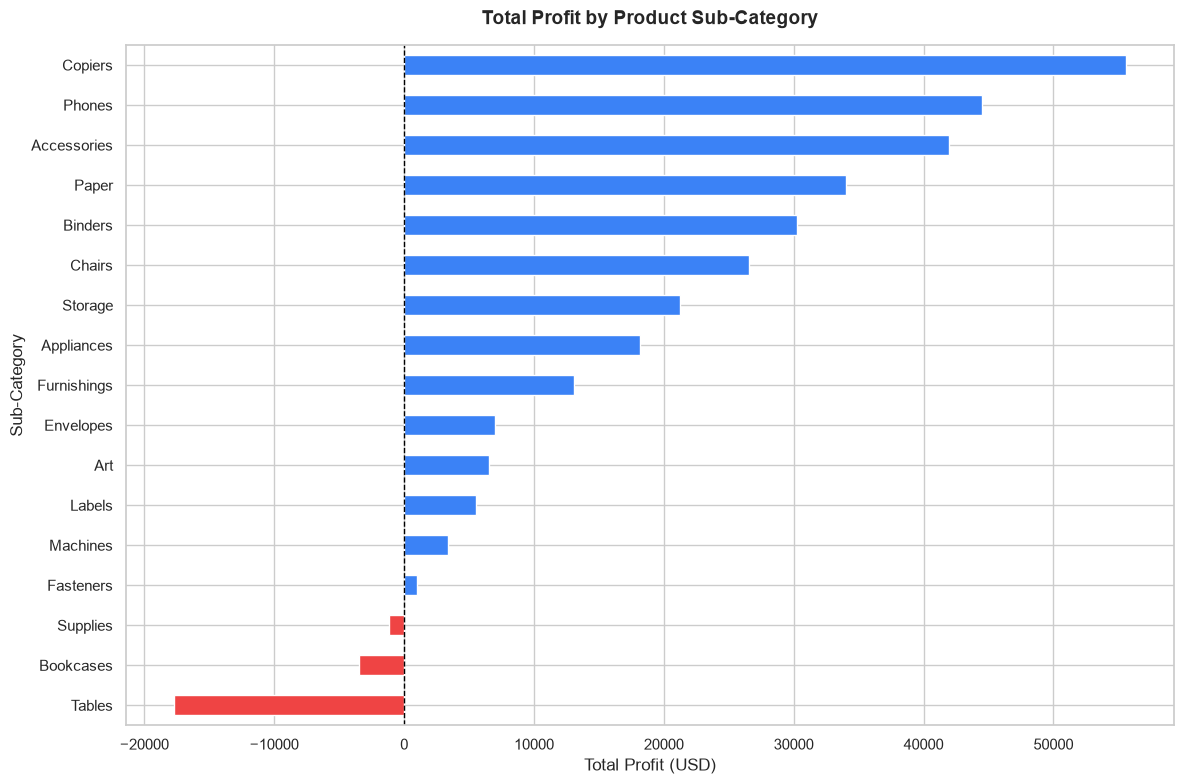

In [3]:
# Aggregate profit by sub-category and sort
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values(ascending=True)

# Plot Horizontal Bar Chart
plt.figure(figsize=(12, 8))
colors = ['#ef4444' if p < 0 else '#3b82f6' for p in subcat_profit]
subcat_profit.plot(kind='barh', color=colors)

plt.title('Total Profit by Product Sub-Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Profit (USD)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

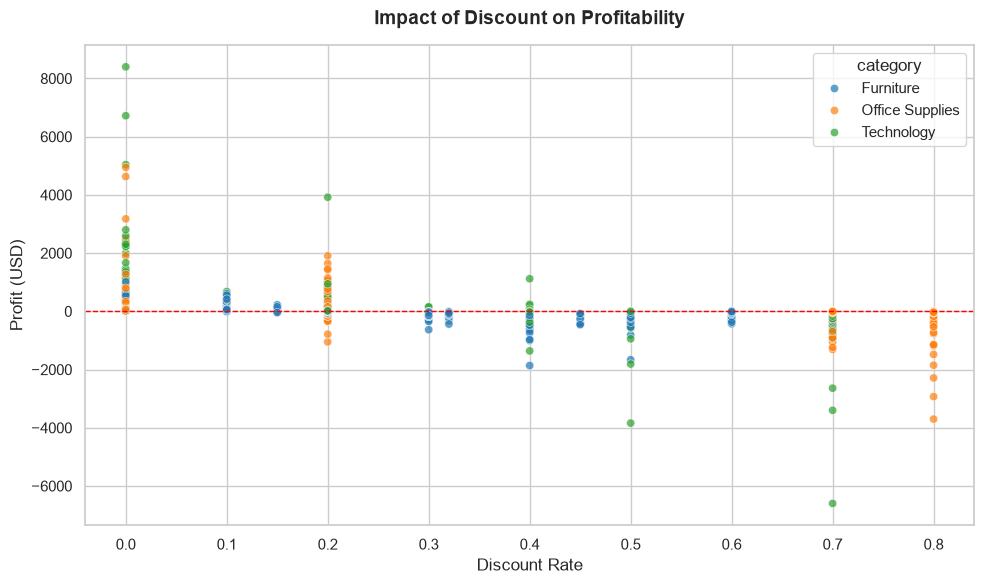

In [4]:
# Scatter plot analyzing relationship between Discount and Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.7, palette='tab10')

plt.title('Impact of Discount on Profitability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit (USD)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [5]:
import os

# Create reports folder if it doesn't exist
os.makedirs('../reports', exist_ok=True)

# 1. Monthly Trends
plt.figure(figsize=(14, 6))
plt.plot(monthly_trends['year_month'], monthly_trends['sales'], marker='o', label='Total Sales', color='#3b82f6', linewidth=2)
plt.plot(monthly_trends['year_month'], monthly_trends['profit'], marker='s', label='Total Profit', color='#10b981', linewidth=2)
plt.title('Superstore Monthly Sales & Profit Trends (2014 - 2017)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Amount (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../reports/monthly_trends.png', dpi=300)
plt.close()

# 2. Sub-Category Profitability
plt.figure(figsize=(12, 8))
colors = ['#ef4444' if p < 0 else '#3b82f6' for p in subcat_profit]
subcat_profit.plot(kind='barh', color=colors)
plt.title('Total Profit by Product Sub-Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Profit (USD)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../reports/subcat_profitability.png', dpi=300)
plt.close()

# 3. Discount vs Profitability
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.7, palette='tab10')
plt.title('Impact of Discount on Profitability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit (USD)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../reports/discount_vs_profit.png', dpi=300)
plt.close()

print("All Week 2 visualizations saved successfully to the 'reports/' folder!")

All Week 2 visualizations saved successfully to the 'reports/' folder!
